In [158]:
import os
import pypsa
import pycountry
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from unit_helpers import (
    tj_to_twh,
    bcm_to_twh,
)

from data_preparing import (
    plot_total_gas_supply,
    add_shared_row_title,
    basic_axis_formatting,
    plot_stacked_bars,
    get_model_pipeline_imports,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    industry_demands,
    rescom_demands,
    plot_country_consumption,
    plot_electricity_mix,
)

In [159]:
path = Path.cwd().parent / 'resources'
regions = gpd.read_file(path / 'regions_onshore_base_s_50.geojson')
path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50__24H-T-H-B-I-A-dist1_2025.nc')

INFO:pypsa.io:Imported network base_s_50__24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [160]:
from gas_validation_data import (
    df_2024_residential,
    df_2024_industrial,
    df_2024_production,
    df_pipeline_imports,
    df_total_supply,
    df_storage_2024,
    df_2024_power,
)

df_2024_residential = bcm_to_twh(df_2024_residential)
df_2024_industrial = bcm_to_twh(df_2024_industrial)
df_2024_production = bcm_to_twh(df_2024_production)
df_pipeline_imports = bcm_to_twh(df_pipeline_imports)
df_total_supply = bcm_to_twh(df_total_supply)
df_storage_2024 = bcm_to_twh(df_storage_2024)
df_2024_power = bcm_to_twh(df_2024_power)

ccon = pd.read_csv(
    'nrg_cb_gas$defaultview_linear_2_0.csv'
)
ccon = (
    ccon.loc[ccon['TIME_PERIOD'] == 2024]
    .set_index('Geopolitical entity (reporting)')
    ['OBS_VALUE']
    .rename('gas_demand')
    .apply(tj_to_twh)
)

def country_name_to_iso2(name):
    name = name.strip()
    try:
        return pycountry.countries.lookup(name).alpha_2
    except LookupError:
        return None

ccon = ccon.copy()
ccon.index = ccon.index.map(country_name_to_iso2)
ccon = ccon[~ccon.index.isnull()]
ccon = ccon.sort_values(ascending=False)

In [161]:
gens = n.generators.index[n.generators.carrier == 'gas']

In [162]:
def plot_power_demand(ax_left, ax_right, n, right_data, fig, i):

    add_shared_row_title(fig, ax_left, ax_right, "EU-27 + UK Power Sector Gas Demand", i)

    powergas = n.links.index[n.links.carrier.isin(['OCGT', 'CCGT'])]
    gas_consumption = n.links_t.p0[powergas].sum(axis=1).mul(n.snapshot_weightings['generators']).mul(1e-6)
    gas_consumption = gas_consumption.groupby(gas_consumption.index.month).sum()

    model_data = gas_consumption.copy()
    model_data.index = right_data.index

    ylim_lower = min(0, right_data.min(), model_data.min())
    ylim_upper = max(right_data.max(), model_data.max())

    pad = 1.1

    ax_left.plot(model_data.index, model_data.values, marker='o', color='royalblue')
    ax_right.plot(right_data.index, right_data.values, marker='o', color='royalblue')

    ax_left.set_ylim(ylim_lower, ylim_upper * pad)
    ax_right.set_ylim(ylim_lower, ylim_upper * pad)

    for ax in [ax_left, ax_right]:
        basic_axis_formatting(ax)

yet to implement other pipeline representation in model!


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

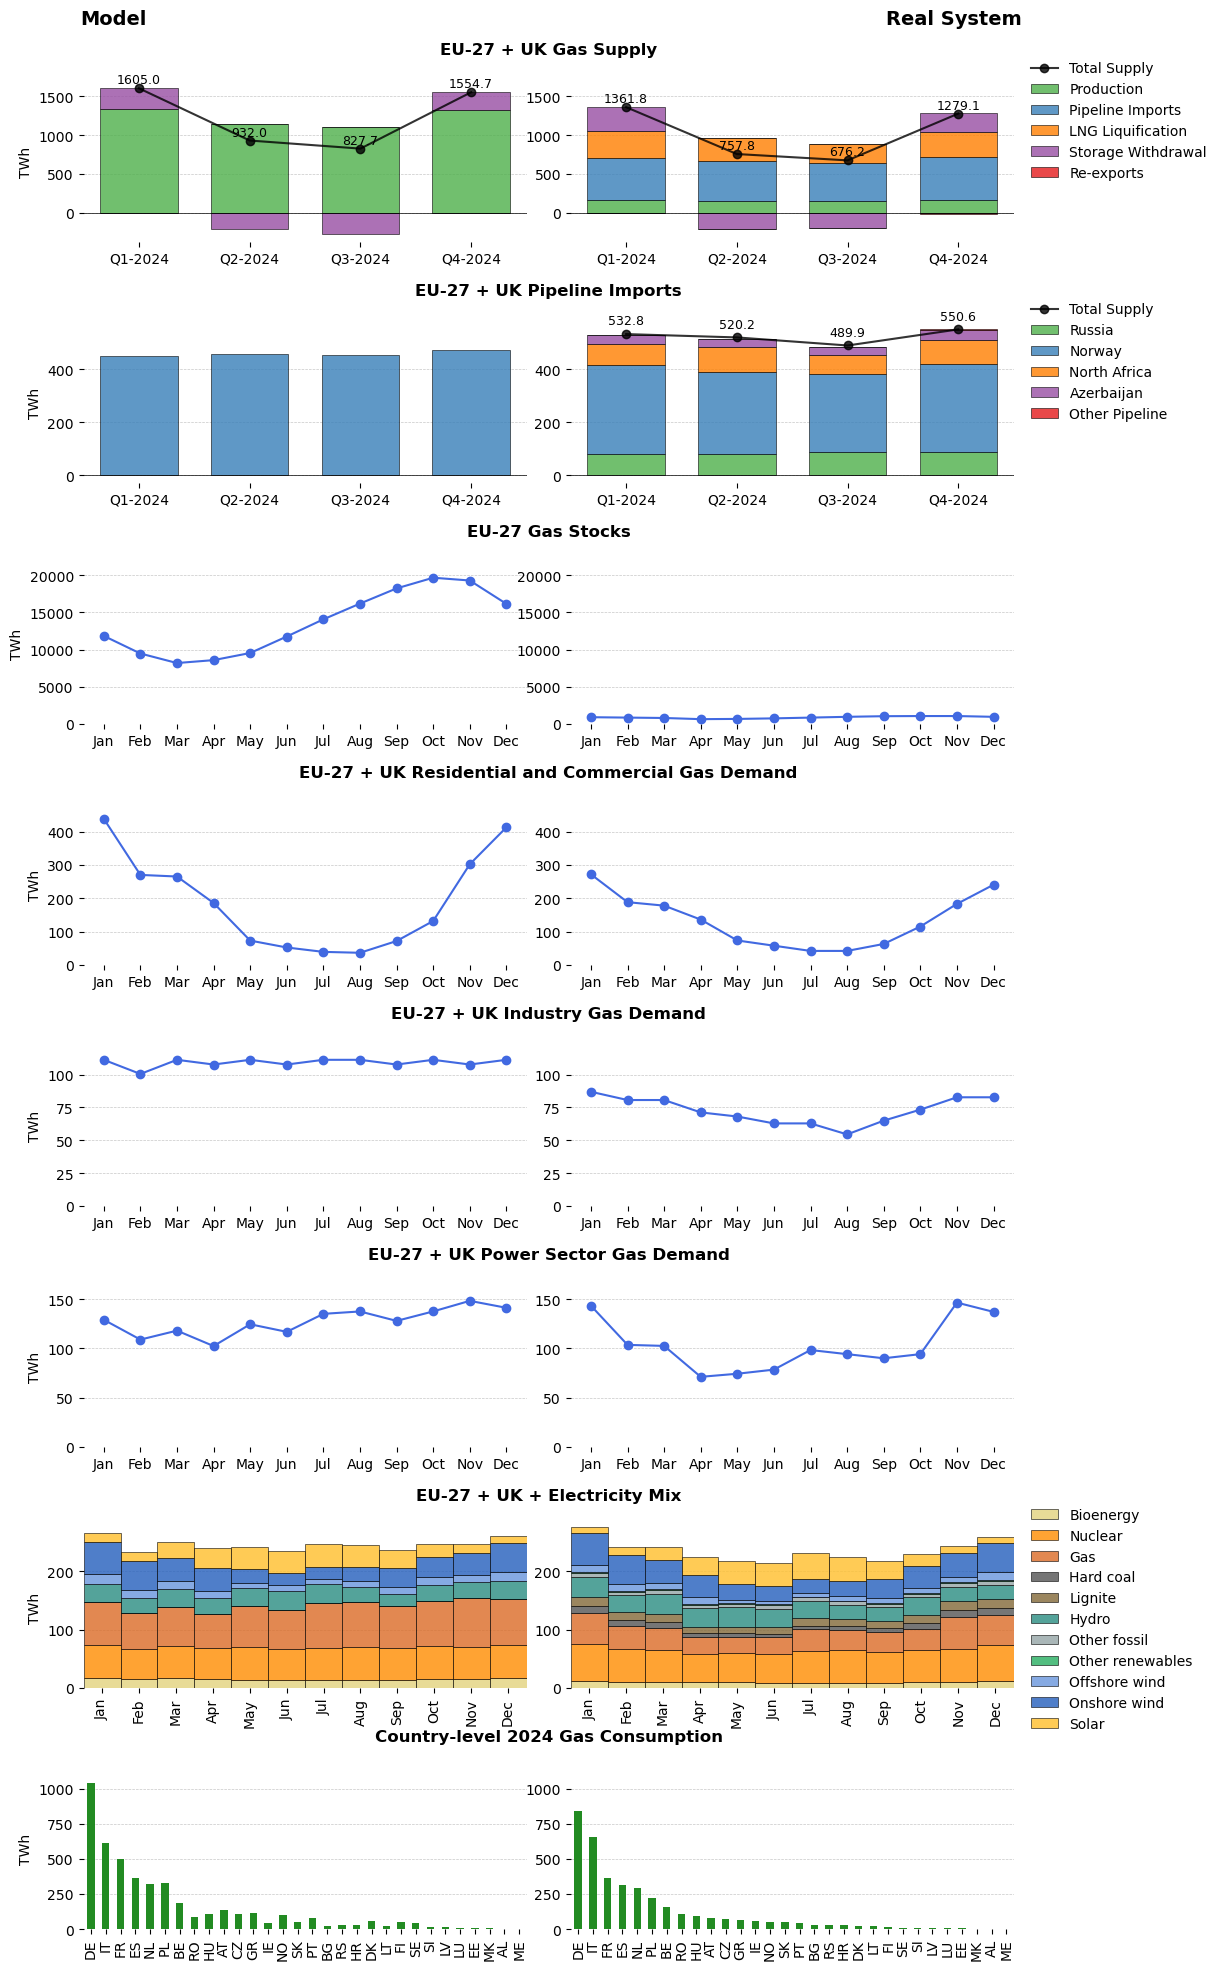

In [163]:
nrows = 8

fig_height = 3 * nrows  # 3 inches per row
fig_width = 12      # 2*2*3 = 12 inches for 2:1 aspect per ax, 2 axes per row
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=2,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace':0.1, 'hspace':0.5}
    )

row_fns = [
    plot_total_gas_supply,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    plot_power_demand,
    plot_electricity_mix,
    plot_country_consumption,
]

right_data_list = [
    df_total_supply,
    df_pipeline_imports,
    df_storage_2024,
    df_2024_residential,
    df_2024_industrial,
    df_2024_power,
    None,
    ccon,
]

for i in range(nrows):
    model_ax = axes[i, 0]
    true_ax = axes[i, 1]
    row_fns[i](model_ax, true_ax, n, right_data_list[i], fig, i)

    model_ax.set_xlabel("")
    model_ax.set_ylabel("")
    true_ax.set_xlabel("")
    true_ax.set_ylabel("")

    fig.canvas.draw()  # Needed to ensure positions are up to date
    bbox1 = model_ax.get_position()
    bbox2 = true_ax.get_position()

    x0 = bbox1.x1 - 0.02 * (bbox2.x0 - bbox1.x1)  # slight overlap
    width = bbox2.x0 - bbox1.x1 + 0.04 * (bbox2.x0 - bbox1.x1)
    y0 = bbox1.y0
    height = bbox1.height

    bbox_top = model_ax.get_position()
    bbox_bottom = model_ax.get_position()
    y0 = bbox_bottom.y0
    height = (bbox_top.y1 - bbox_bottom.y0) / 5

    '''
    rect = patches.FancyBboxPatch(
        (x0, y0), width, height,
        boxstyle="round,pad=0.02",
        linewidth=1, edgecolor='gray', facecolor='white', alpha=0.95,
        transform=fig.transFigure, zorder=10
    )

    fig.patches.append(rect)

    fig.text(
        x0 + width/2, y0 + height/2,
        f"Legend/Explanation\nPlaceholder\n(Row {i+1})",
        ha='center', va='center', fontsize=10, color='black', zorder=11
    )
    '''

fig.text(0.15, 0.91, 'Model', ha='center', va='top', fontsize=14, fontweight='bold')
fig.text(0.85, 0.91, 'Real System', ha='center', va='top', fontsize=14, fontweight='bold')

for ax in axes[:,0]:
    ax.set_ylabel('TWh')

# plt.savefig('validation_starting_point.pdf', bbox_inches='tight')
plt.show()

In [164]:
ss = n.statistics.energy_balance(groupby=['carrier', 'bus'])

ss.loc[
    (ss.index.get_level_values(2).str.contains('gas')) &
    (ss.index.get_level_values(2).str.contains('NO')) &
    (ss.index.get_level_values(1) == 'gas pipeline')
]

component  carrier       bus      
Link       gas pipeline  NO1 0 gas   -1833.3824
dtype: float64

In [71]:
pipes = n.links.index[n.links.carrier == 'gas pipeline']

In [72]:
def get_link_data(c):
    l = n.links.index[n.links.carrier == c]

    cols = ['marginal_cost', 'efficiency', 'capital_cost', 'p_nom', 'p_nom_opt']
    print(n.links.loc[[l[0]], cols])

In [73]:
get_link_data('OCGT')

                 marginal_cost  efficiency  capital_cost  p_nom  p_nom_opt
Link                                                                      
AL0 0 OCGT-2025       1.938258       0.405  19739.577493    0.0   0.029715


In [74]:
get_link_data('CCGT')

                 marginal_cost  efficiency  capital_cost  p_nom  p_nom_opt
Link                                                                      
AL0 0 CCGT-2025       2.604208        0.57   61475.63654    0.0   0.026111


In [75]:
get_link_data('coal')

                 marginal_cost  efficiency   capital_cost        p_nom  \
Link                                                                     
DE0 2 coal-1950       1.171613       0.356  120046.057771  2134.831461   

                   p_nom_opt  
Link                          
DE0 2 coal-1950  2134.831461  


In [76]:
ss = n.links.loc[n.links.carrier.isin(['OCGT', 'CCGT', 'coal', 'lignite'])]
ss.groupby('carrier')[['p_nom', 'p_nom_opt']].sum() / 1e3

,p_nom,p_nom_opt
carrier,,
CCGT,320.815959,339.680444
OCGT,0.057556,0.059263
coal,137.859267,137.859267
lignite,157.953647,157.953647


In [77]:
n.generators.loc[n.generators.carrier.isin(['gas', 'coal', 'lignite']), ['marginal_cost', 'capital_cost', 'carrier']].groupby('carrier').mean()

,marginal_cost,capital_cost
carrier,,
coal,9.564568,0.0
gas,24.578073,0.0
lignite,3.307587,0.0


In [78]:
prices = pd.read_csv(
    Path.cwd().parent / 'data' / 'TERMINAL - PA historical - 2025-10-21.csv', index_col=0, parse_dates=True
)

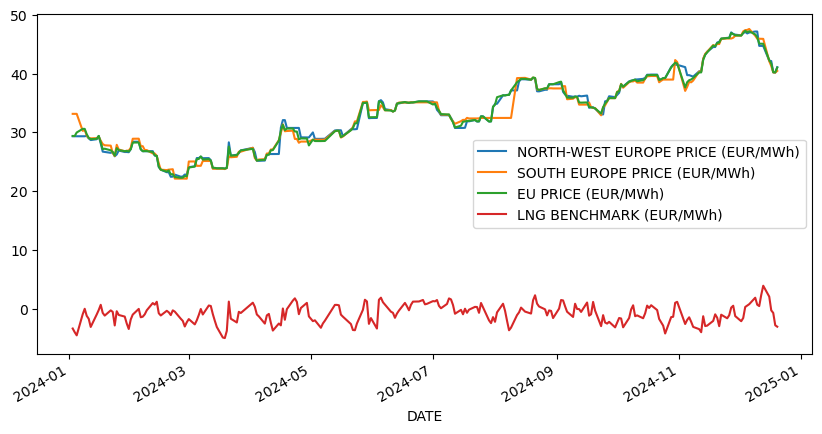

In [79]:
fig, ax = plt.subplots(figsize=(10, 5))
prices.index = pd.to_datetime(prices.index)
prices.loc['2024'].plot(ax=ax)
plt.show()

In [80]:
wbprices = pd.read_excel(
    Path.cwd().parent / 'data' / 'CMO-Historical-Data-Monthly.xlsx', sheet_name='Monthly Prices', header=[4,5,6], index_col=0, parse_dates=True,
)
wbprices = wbprices.loc[wbprices.index.str.contains('2024')]

gas_keepers = ['Natural gas, Europe', 'Liquefied natural gas, Japan']
coal_keepers = ['Coal, Australian', 'Coal, South African **']

wbprices = wbprices.loc[:, gas_keepers + coal_keepers]
wbprices.index = list(map(lambda x: f'{x[:4]}-{x[-2:]}', wbprices.index))

wbprices.columns = wbprices.columns.get_level_values(0)

wbprices.loc[:, gas_keepers] *= 3.152 # conversion from $/MMBtu to EUR/MWh

wbprices.loc[:, 'Lignite'] = 0.1325 * 6000 / 2800 * wbprices.loc[:, 'Coal, Australian']
 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)
wbprices.loc[:, 'Coal, Australian'] *= 0.1325 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)
wbprices.loc[:, 'Coal, South African **'] *= 0.1325 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)

wbprices.rename(
    columns={
        'Natural gas, Europe': 'Europe gas',
        'Liquefied natural gas, Japan': 'Japan LNG',
        'Coal, Australian': 'Australia coal',
        'Coal, South African **': 'South Africa coal',
    },
    inplace=True,
)
wbprices.index = pd.to_datetime(wbprices.index)

/tmp/ipykernel_169122/3515084156.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wbprices = pd.read_excel(


In [81]:
em = pd.read_csv(
    Path.cwd().parent / 'data' / 'europe_monthly_full_release_long_format.csv', index_col=[1,2]
)

em = em.loc[
    (em['Unit'] == 'TWh') &
    (em['Subcategory'] == 'Fuel')
    ]

In [82]:
em = em.set_index('Variable', append=True)
em = em.loc[em.Area.isin(['EU', 'United Kingdom'])]

em = em.groupby([em.index.get_level_values(2), em.index.get_level_values(1).str[:7]])['Value'].sum().unstack()
em = em.loc[:, em.columns.str.contains('2024')]

In [83]:
em.sum().sum()

2825.89

In [84]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [85]:
w = n.snapshot_weightings.generators.iloc[0]

In [86]:
el = n.loads.index[(n.loads.carrier == 'electricity') & (~n.loads.index.str.contains(' NO'))]
total_elec_load = (
    n.loads.loc[
        n.loads.carrier.isin(['agriculture electricity', 'industry electricity']) &
        (~n.loads.index.str.contains(' NO')),
        'p_set'].sum() * len(n.snapshots) +
    n.loads_t.p_set.loc[:, el].sum().sum()
) * w * 1e-6
withdrawers = n.links.loc[list(map(lambda x: 'low voltage' in x, n.links.bus0))].index
withdrawers = withdrawers[~withdrawers.str.contains('NO ')]
heating_transport_demand = n.links_t.p0.loc[:, withdrawers].sum().sum() * w * 1e-6

total_elec_load += heating_transport_demand
total_elec_load

3090.1825683420543

In [87]:
n.buses.carrier.unique()

array(['AC', 'lignite', 'coal', 'oil', 'oil primary', 'uranium', 'none',
       'co2', 'co2 stored', 'co2 sequestered', 'gas', 'H2', 'battery',
       'EV battery', 'land transport oil', 'urban central heat', 'biogas',
       'solid biomass', 'unsustainable bioliquids', 'NH3', 'methanol',
       'solid biomass for industry', 'gas for industry',
       'industry methanol', 'naphtha for industry', 'non-sequestered HVC',
       'process emissions', 'coal for industry', 'shipping oil',
       'kerosene for aviation', 'agriculture machinery oil',
       'low voltage', 'home battery', 'rural heat',
       'urban decentral heat'], dtype=object)

In [88]:
demands = ['urban central heat', 'urban decentral heat', 'rural heat']

heat_buses = n.buses.index[n.buses.carrier.isin(demands)]

heat_generators = n.generators.index[n.generators.bus.isin(heat_buses)]
heat_generator_carriers = n.generators.loc[heat_generators, 'carrier'].unique()

heat_links = n.links.index[n.links.bus0.isin(heat_buses) | n.links.bus1.isin(heat_buses) | n.links.bus2.isin(heat_buses) | n.links.bus3.isin(heat_buses)]
heat_link_carriers = n.links.loc[heat_links, 'carrier'].unique()

heat_loads = n.loads.index[n.loads.bus.isin(heat_buses)]
heat_load_carriers = n.loads.loc[heat_loads, 'carrier'].unique()

all_heat_carriers = pd.Index(heat_generator_carriers).union(pd.Index(heat_link_carriers))

In [165]:
import yaml

with open(Path.cwd().parent / 'config.basicrun.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

In [166]:
idx = pd.IndexSlice

eb = n.statistics.energy_balance(groupby=['carrier', 'bus'])
eb = eb.loc[idx[:, :, heat_buses]]
eb = eb.groupby([eb.index.get_level_values(1), eb.index.get_level_values(2).str[:2]]).sum()
eb = eb.loc[eb > 0].unstack().replace(np.nan, 0)
eb = eb.loc[eb.sum(axis=1).sort_values(ascending=False).index, eb.sum().sort_values(ascending=False).index].mul(1e-6)

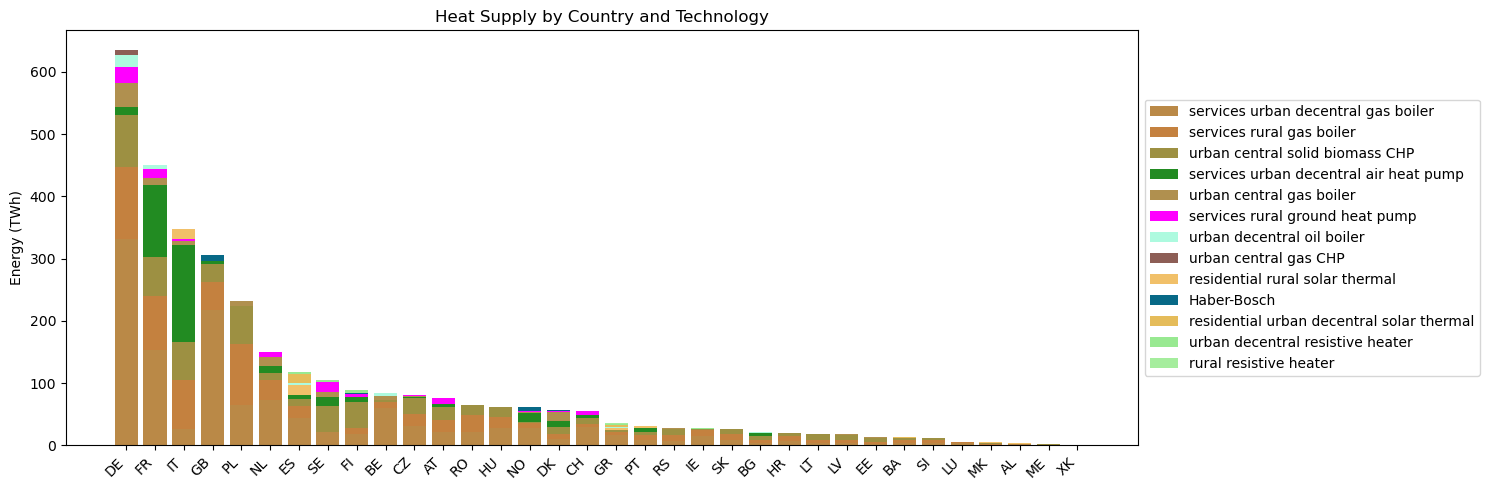

In [167]:
fig, ax = plt.subplots(figsize=(15, 5))

for i, c in enumerate(eb.columns):
    col_data = eb[c]
    col_total = col_data.sum()
    
    # Filter for carriers contributing more than 1%
    significant = col_data[col_data > 0.01 * col_total]
    
    # Get colors for each carrier
    colors = [tech_colors.get(carrier, '#808080') for carrier in significant.index]
    
    # Create stacked bar
    bottom = 0
    for carrier, value in significant.items():
        color = tech_colors.get(carrier, '#808080')
        ax.bar(i, value, bottom=bottom, color=color, label=carrier, width=0.8)
        bottom += value

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xticks(range(len(eb.columns)))
ax.set_xticklabels(eb.columns, rotation=45, ha='right')
ax.set_ylabel('Energy (TWh)')
ax.set_title('Heat Supply by Country and Technology')

plt.tight_layout()

plt.show()

In [168]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [169]:
ss = n.links.loc[n.links.carrier.isin(eb.index)]
ss = ss.groupby(['carrier', 'bus1'])['p_nom_opt'].sum().unstack()
ss = ss.T.groupby(ss.columns.str[:2]).sum().T.mul(1e-3)
ss.columns = ss.columns.str[:2]
ss = ss.loc[ss.sum(axis=1) > 0]
ss = ss.loc[:, ss.sum().sort_values(ascending=False).index]

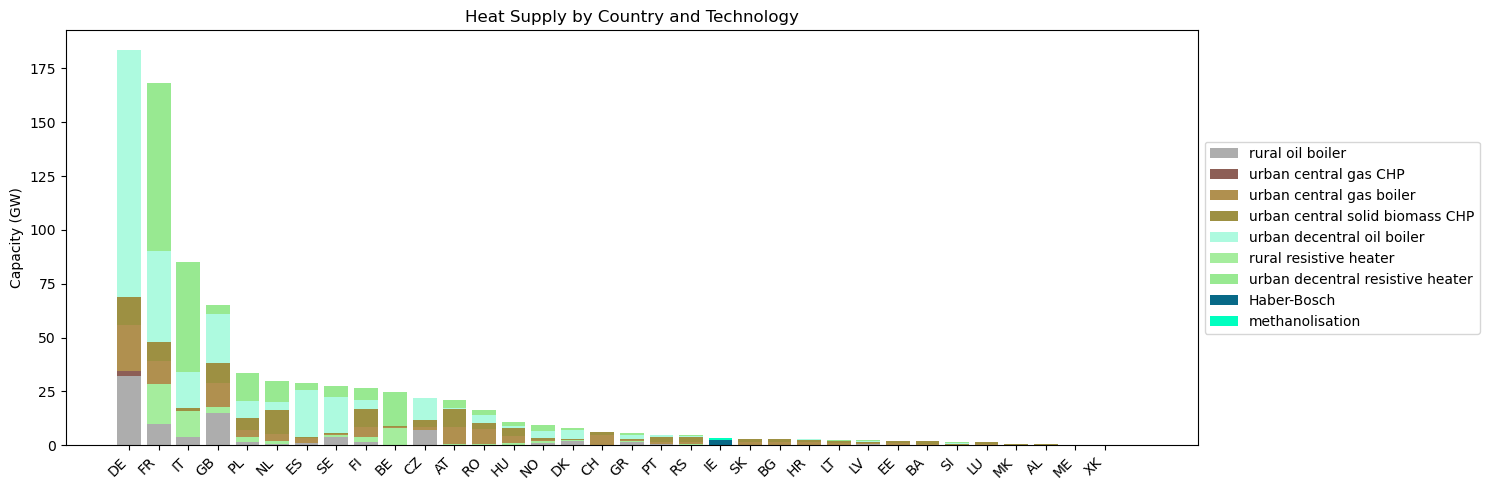

In [170]:

fig, ax = plt.subplots(figsize=(15, 5))

for i, c in enumerate(ss.columns):
    col_data = ss[c]
    col_total = col_data.sum()
    
    # Filter for carriers contributing more than 1%
    significant = col_data[col_data > 0.01 * col_total]
    
    # Get colors for each carrier
    colors = [tech_colors.get(carrier, '#808080') for carrier in significant.index]
    
    # Create stacked bar
    bottom = 0
    for carrier, value in significant.items():
        color = tech_colors.get(carrier, '#808080')
        ax.bar(i, value, bottom=bottom, color=color, label=carrier, width=0.8)
        bottom += value

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xticks(range(len(eb.columns)))
ax.set_xticklabels(eb.columns, rotation=45, ha='right')
ax.set_ylabel('Capacity (GW)')
ax.set_title('Heat Supply by Country and Technology')

plt.tight_layout()

plt.show()

In [171]:
cf = n.statistics()['Capacity Factor']

In [172]:
n.links.index[n.links.index.str.contains('residential')]

Index([], dtype='object', name='Link')

In [173]:
'residential urban decentral gas boiler' in n.links.carrier.unique()

False

In [174]:
heat_carriers = [
    'urban decentral heat',
    'urban central heat',
    'rural heat',
]

urban_decentral_b = n.buses.index[
    n.buses.carrier.isin(heat_carriers)
    ]

carriers = n.links.loc[n.links.bus1.isin(urban_decentral_b), 'carrier'].unique()

supply = pd.DataFrame(index=n.snapshots, columns=carriers)

for c in carriers:
    supply.loc[:, c] = n.links_t.p1.loc[:, n.links.carrier == c].sum(axis=1).mul(-1e-3)

supply = supply.groupby(lambda x: ' '.join(x.split()[-2:]), axis=1).sum()
supply = supply.div(supply.sum(axis=1), axis=0)

/tmp/ipykernel_169122/2054643727.py:18: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  supply = supply.groupby(lambda x: ' '.join(x.split()[-2:]), axis=1).sum()


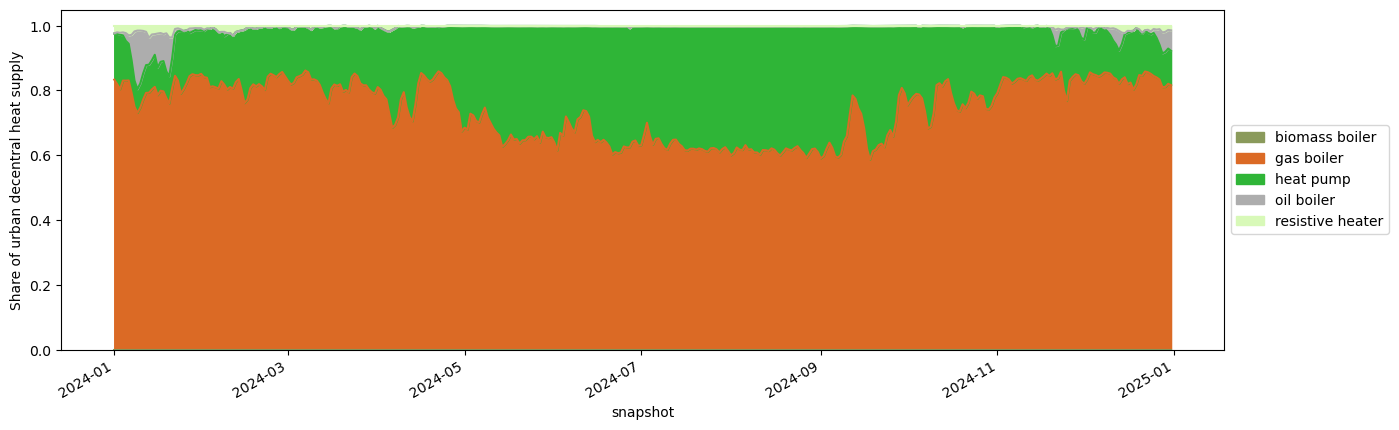

In [175]:
fig, ax = plt.subplots(figsize=(15, 5))
import random
colors = [tech_colors.get(carrier, f'#{random.randint(0, 0xFFFFFF):06x}') for carrier in supply.columns]

supply.plot.area(ax=ax, color=colors, legend=False)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('Share of urban decentral heat supply')
plt.show()

/tmp/ipykernel_169122/2518118413.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


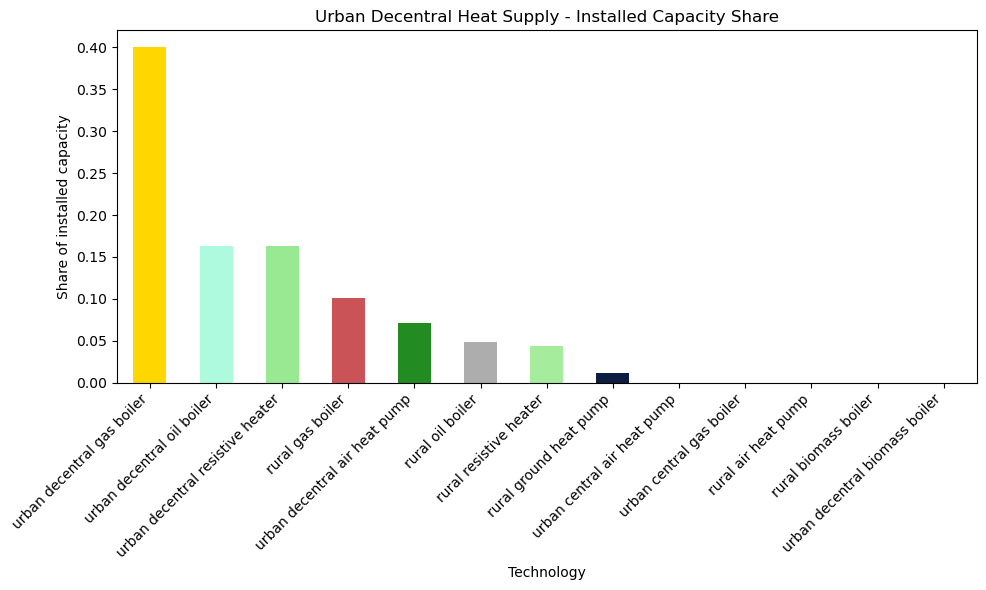

In [176]:
installed_cap = pd.Series(index=carriers)

for c in carriers:

    ls = n.links.index[n.links.carrier == c]

    if ls.isin(n.links_t.efficiency.columns).any():
        assert ls.isin(n.links_t.efficiency.columns).all()

        eff = n.links_t.efficiency.loc[:, ls].mean()
        heat_cap = n.links.loc[ls, 'p_nom_opt'].mul(eff).mul(1e-3)
        installed_cap.loc[c] = heat_cap.sum()

    else:
        installed_cap.loc[c] = n.links.loc[ls, 'p_nom'].mul(1e-3).mul(n.links.loc[ls, 'efficiency']).sum()

installed_cap = installed_cap.sort_values(ascending=False) / installed_cap.sum()
# %% cell 37b code

fig, ax = plt.subplots(figsize=(10, 6))

# Create stacked bar plot
colors = [tech_colors.get(carrier, f'#{random.randint(0, 0xFFFFFF):06x}') for carrier in installed_cap.index]

installed_cap.plot.bar(ax=ax, color=colors, stacked=False)

ax.set_ylabel('Share of installed capacity')
ax.set_xlabel('Technology')
ax.set_title('Urban Decentral Heat Supply - Installed Capacity Share')
ax.legend().set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [132]:
heat_carriers

['urban decentral heat', 'rural heat']

<Axes: xlabel='snapshot'>

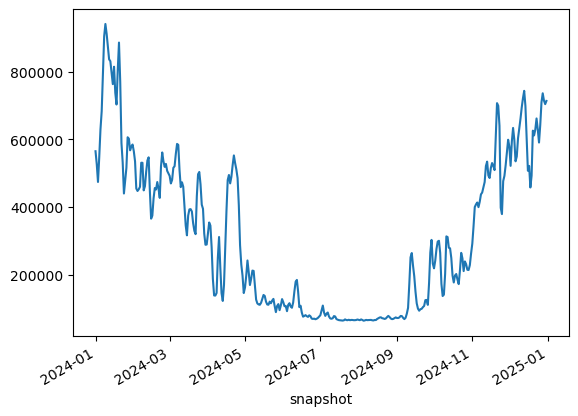

In [157]:
heatloads = n.loads.index[n.loads.carrier.isin(['urban central heat', 'urban decentral heat', 'rural heat'])]
n.loads_t.p_set.loc[:, heatloads.intersection(n.loads_t.p_set.columns)].sum(axis=1).plot()

In [155]:
n.links.loc[n.links.carrier.isin(installed_cap.index)].groupby('carrier')['p_nom_extendable'].first()

carrier
rural air heat pump                  True
rural biomass boiler                 True
rural gas boiler                     True
rural ground heat pump               True
rural oil boiler                    False
rural resistive heater              False
urban central air heat pump         False
urban central gas boiler            False
urban decentral air heat pump        True
urban decentral biomass boiler       True
urban decentral gas boiler           True
urban decentral oil boiler          False
urban decentral resistive heater    False
Name: p_nom_extendable, dtype: bool

<Axes: xlabel='snapshot'>

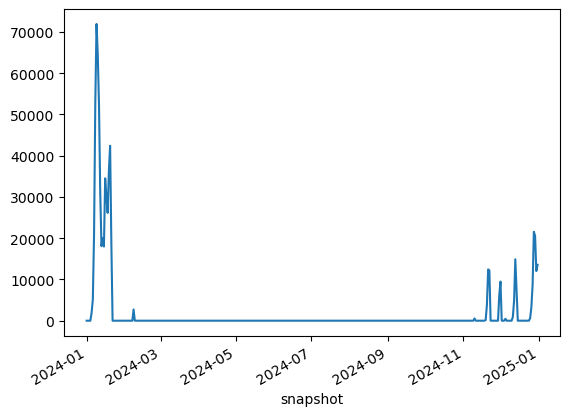

In [ ]:
n.links_t.p0.loc[:, boilers].sum(axis=1).plot()

In [ ]:
caps = n.statistics.optimal_capacity(groupby=['carrier', 'bus']).loc[idx['Link']]
relevant_tech = caps.index.get_level_values(0).unique().intersection(all_heat_carriers)
caps = caps.loc[idx[relevant_tech]]
caps = caps.groupby([caps.index.get_level_values(0), caps.index.get_level_values(1).str[:2]]).sum()
caps = caps.loc[caps > 0].unstack().replace(np.nan, 0)
caps = caps.loc[caps.sum(axis=1).sort_values(ascending=False).index, caps.sum().sort_values(ascending=False).index].mul(1e-3)

In [ ]:
n.links.loc[n.links.carrier == 'urban decentral air heat pump']

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,reversed,project_status,geometry,dc,under_construction,voltage,length_original,underground,tags,underwater_fraction
Link,,,,,,,,,,,,,,,,,,,,,
AL0 0 urban decentral air heat pump-2025,AL0 0 low voltage,AL0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN
AT0 0 urban decentral air heat pump-2010,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2010,18.0,73.469388,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
AT0 0 urban decentral air heat pump-2015,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2015,18.0,73.469388,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
AT0 0 urban decentral air heat pump-2019,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2019,18.0,58.775510,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
AT0 0 urban decentral air heat pump-2025,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SE1 0 urban decentral air heat pump-2019,SE1 0 low voltage,SE1 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2019,18.0,279.183673,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
SE1 0 urban decentral air heat pump-2025,SE1 0 low voltage,SE1 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN
SI0 0 urban decentral air heat pump-2025,SI0 0 low voltage,SI0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN


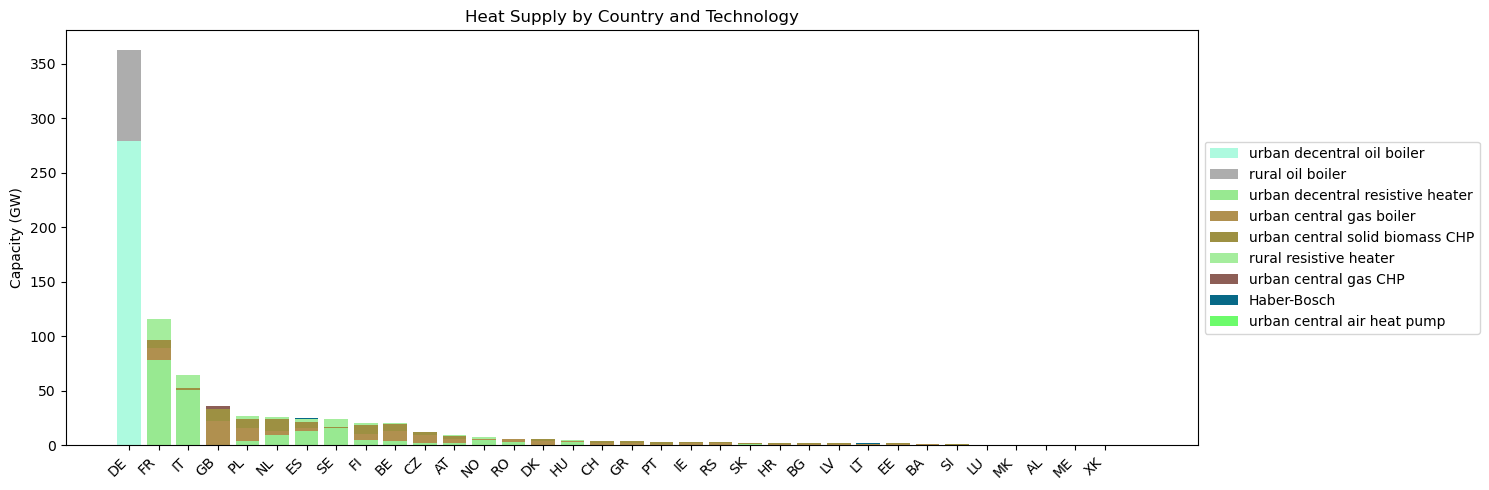

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

for i, c in enumerate(caps.columns):
    col_data = caps[c]
    col_total = col_data.sum()
    
    # Filter for carriers contributing more than 1%
    significant = col_data[col_data > 0.01 * col_total]
    
    # Get colors for each carrier
    colors = [tech_colors.get(carrier, '#808080') for carrier in significant.index]
    
    # Create stacked bar
    bottom = 0
    for carrier, value in significant.items():
        color = tech_colors.get(carrier, '#808080')
        ax.bar(i, value, bottom=bottom, color=color, label=carrier, width=0.8)
        bottom += value

# Add legend on the right
handles, labels = ax.get_legend_handles_labels()
# Remove duplicates while preserving order
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1, 0.5))

# Set x-axis labels
ax.set_xticks(range(len(eb.columns)))
ax.set_xticklabels(eb.columns, rotation=45, ha='right')
ax.set_ylabel('Capacity (GW)')
ax.set_title('Heat Supply by Country and Technology')

plt.tight_layout()

plt.show()

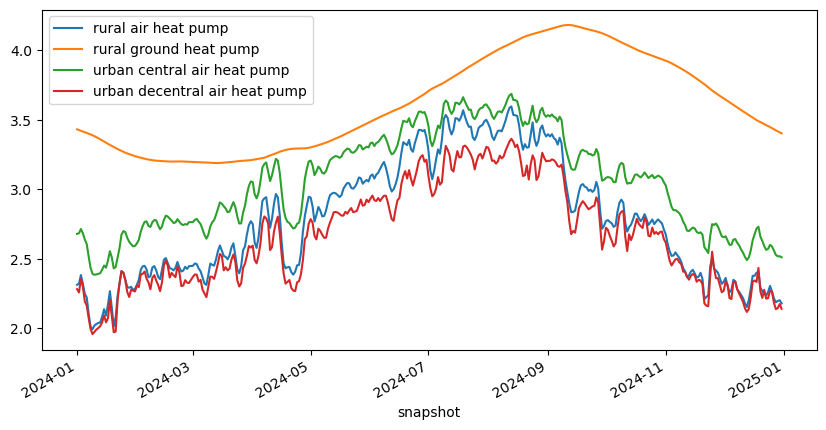

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for c in hps:

    cops = n.links_t.efficiency.loc[:, n.links.carrier == c].mean(axis=1)
    cops.plot(ax=ax, label=c)

ax.legend()
plt.show()

In [ ]:
eh = pd.read_csv(
    Path.cwd().parent / 'resources' / 'existing_heating_distribution_base_s_50_2025.csv',
    index_col=0,
    header=[0,1]
)
eh

heat name  urban central                                            \
technology    gas boiler oil boiler resistive heater air heat pump   
name                                                                 
AL0 0                0.0        0.0              0.0           0.0   
AT0 0                0.0        0.0              0.0           0.0   
BA0 0                0.0        0.0              0.0           0.0   
BE0 0                0.0        0.0              0.0           0.0   
BG0 0                0.0        0.0              0.0           0.0   
CH0 0                0.0        0.0              0.0           0.0   
CZ0 0                0.0        0.0              0.0           0.0   
DE0 0                0.0        0.0              0.0           0.0   
DE0 1                0.0        0.0              0.0           0.0   
DE0 2                0.0        0.0              0.0           0.0   
DE0 3                0.0        0.0              0.0           0.0   
DE0 4                0.0        0.0              0.0           0.0   
DE0 5                0.0        0.0              0.0           0.0   
DK0 0                0.0        0.0              0.0           0.0   
DK1 0                0.0        0.0              0.0           0.0   
EE0 0                0.0        0.0              0.0           0.0   
ES0 0                0.0        0.0              0.0           0.0   
ES6 0                0.0        0.0              0.0           0.0   
FI1 0                0.0        0.0              0.0           0.0   
FR0 0                0.0        0.0              0.0           0.0   
FR0 1                0.0        0.0              0.0           0.0   
FR0 2                0.0        0.0              0.0           0.0   
FR0 3                0.0        0.0              0.0           0.0   
FR0 4                0.0        0.0              0.0           0.0   
FR5 0                0.0        0.0              0.0           0.0   
GB2 0                0.0        0.0              0.0           0.0   
GB2 1                0.0        0.0              0.0           0.0   
GB3 0                0.0        0.0              0.0           0.0   
GR0 0                0.0        0.0              0.0           0.0   
HR0 0                0.0        0.0              0.0           0.0   
HU0 0                0.0        0.0              0.0           0.0   
IE3 0                0.0        0.0              0.0           0.0   
IT0 0                0.0        0.0              0.0           0.0   
IT0 1                0.0        0.0              0.0           0.0   
IT4 0                0.0        0.0              0.0           0.0   
LT0 0                0.0        0.0              0.0           0.0   
LU0 0                0.0        0.0              0.0           0.0   
LV0 0                0.0        0.0              0.0           0.0   
ME0 0                0.0        0.0              0.0           0.0   
MK0 0                0.0        0.0              0.0           0.0   
NL0 0                0.0        0.0              0.0           0.0   
NO1 0                0.0        0.0              0.0           0.0   
PL0 0                0.0        0.0              0.0           0.0   
PT0 0                0.0        0.0              0.0           0.0   
RO0 0                0.0        0.0              0.0           0.0   
RS0 0                0.0        0.0              0.0           0.0   
SE1 0                0.0        0.0              0.0           0.0   
SI0 0                0.0        0.0              0.0           0.0   
SK0 0                0.0        0.0              0.0           0.0   
XK0 0                0.0        0.0              0.0           0.0   

heat name                   residential rural                                 \
technology ground heat pump        gas boiler    oil boiler resistive heater   
name                                                                           
AL0 0                   0.0          0.000000    

In [ ]:
ss = n.links.loc[
    (n.links.carrier.isin(heat_link_carriers)) &
    (n.links.p_nom > 0)
    ]

In [ ]:
ss['p_nom_extendable'].value_counts()

p_nom_extendable
False    866
Name: count, dtype: int64

In [ ]:
eb.index.get_level_values(1).unique().intersection(all_heat_carriers)

Index(['Fischer-Tropsch', 'H2 Electrolysis', 'Haber-Bosch', 'Sabatier',
       'rural oil boiler', 'rural resistive heater',
       'urban central air heat pump', 'urban central gas CHP',
       'urban central gas CHP CC', 'urban central gas boiler',
       'urban central solid biomass CHP', 'urban central solid biomass CHP CC',
       'urban decentral oil boiler', 'urban decentral resistive heater',
       'urban central heat vent', 'urban central solar thermal'],
      dtype='object')

In [ ]:
all_heat_carriers.difference(eb.index.get_level_values(1).unique())

Index(['rural air heat pump', 'rural biomass boiler', 'rural gas boiler',
       'rural ground heat pump', 'rural heat vent', 'rural solar thermal',
       'urban decentral air heat pump', 'urban decentral biomass boiler',
       'urban decentral gas boiler', 'urban decentral heat vent',
       'urban decentral solar thermal'],
      dtype='object')

In [ ]:
eb.loc[idx[:, all_heat_carriers, :]]

KeyError: 'rural air heat pump'

In [ ]:
eb

component  carrier                           bus                       
Load       urban central heat                AL0 0 urban central heat     -1.425733e+05
                                             AT0 0 urban central heat     -1.133302e+07
                                             BA0 0 urban central heat     -1.275190e+06
                                             BE0 0 urban central heat     -5.350373e+06
                                             BG0 0 urban central heat     -3.292160e+06
                                                                               ...     
           residential urban decentral heat  RS0 0 urban decentral heat   -6.642115e+06
                                             SE1 0 urban decentral heat   -3.994959e+07
                                             SI0 0 urban decentral heat   -4.526603e+06
                                             SK0 0 urban decentral heat   -8.761170e+06
                                             XK0

In [124]:
n.links.carrier.unique()

array(['DC', 'oil refining', 'co2 sequestered', 'OCGT', 'CCGT',
       'H2 Electrolysis', 'gas pipeline', 'gas pipeline new',
       'battery charger', 'battery discharger', 'Sabatier', 'SMR CC',
       'SMR', 'BEV charger', 'V2G', 'land transport oil',
       'urban central air heat pump', 'urban central gas boiler',
       'urban central gas CHP', 'urban central gas CHP CC',
       'unsustainable bioliquids', 'biogas to gas',
       'urban central solid biomass CHP',
       'urban central solid biomass CHP CC', 'biomass to liquid',
       'electrobiofuels', 'Haber-Bosch', 'ammonia cracker',
       'biomass-to-methanol', 'OCGT methanol',
       'solid biomass for industry', 'solid biomass for industry CC',
       'gas for industry', 'gas for industry CC', 'industry methanol',
       'methanolisation', 'Fischer-Tropsch', 'naphtha for industry',
       'HVC to air', 'process emissions', 'process emissions CC',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       '

In [ ]:
n.stores.loc['co2 atmosphere', 'e_nom_opt'] / 1e9


###################################################################



#####        THE OLD IMPLEMENTATION HAD 2.42 Gt CO2 in emissions


####################################################################

2.420959751521577

In [127]:
print(f'with-ets-emissions [GtCO2]: {n.generators_t.p.loc[:, n.generators.carrier == 'co2-ets'].sum().sum() * w * -1e-9:.3f}')

with-ets-emissions [GtCO2]: 2.346


In [128]:
n.stores.carrier.unique()

array(['lignite', 'coal', 'oil', 'uranium', 'co2 stored',
       'co2 sequestered', 'gas', 'H2 Store', 'battery', 'EV battery',
       'ammonia store', 'methanol', 'non-sequestered HVC', 'home battery'],
      dtype=object)

In [129]:
n.stores.loc[n.stores.carrier == 'gas', ['e_nom_opt', 'e_nom', 'e_nom_max']]

,e_nom_opt,e_nom,e_nom_max
Store,,,
AL0 0 gas Store,1.168756e+04,0.0,inf
AT0 0 gas Store,8.728176e+07,0.0,inf
BA0 0 gas Store,5.261971e+03,0.0,inf
BE0 0 gas Store,5.452852e+05,0.0,inf
BG0 0 gas Store,5.680006e+06,0.0,inf
CH0 0 gas Store,7.645600e+02,0.0,inf
CZ0 0 gas Store,3.671295e+07,0.0,inf
DE0 0 gas Store,9.225875e+07,0.0,inf
DE0 1 gas Store,3.472964e+07,0.0,inf


In [130]:
final_carriers = ['Wind Onshore', 'Wind Offshore', 'Coal', 'Lignite', 'Gas', 'Hydro', 'Nuclear', 'Solar', 'Biomass', 'Waste', 'Geothermal']

In [147]:
eu_mapping = {
    'Biomass': 'Biomass',
    'Waste': 'Waste',
    'Fossil Brown coal/Lignite': 'Lignite',
    'Fossil Hard coal': 'Coal',
    'Fossil Coal-derived gas': 'Gas',
    'Fossil Gas': 'Gas',
    'Fossil Oil': 'Gas',
    'Fossil Oil shale': 'Gas',
    'Fossil Peat': 'Gas',
    'Geothermal': 'Geothermal',
    'Hydro Pumped Storage': 'Hydro',
    'Hydro Run-of-river and poundage': 'Hydro',
    'Hydro Water Reservoir': 'Hydro',
    'Marine': 'Hydro',
    'Nuclear': 'Nuclear',
    'Other': 'Gas',
    'Other renewable': 'Biomass',
    'Solar': 'Solar',
    'Wind Offshore': 'Wind Offshore',
    'Wind Onshore': 'Wind Onshore',
}

uk_mapping = {
    'Coal [note 4]': 'Coal',
    'Oil [note 5]': 'Gas',
    'OCGT and conventional thermal gas [note 5]': 'Gas',
    'CCGT gas': 'Gas',
    'Nuclear - Magnox': 'Nuclear',
    'Nuclear - PWR': 'Nuclear',
    'Nuclear - AGR': 'Nuclear',
    'Hydro (natural flow)': 'Hydro',
    'Wind (onshore)': 'Wind Onshore',
    'Wind (offshore)': 'Wind Offshore',
    'Solar': 'Solar',
    'Wave and tidal': 'Hydro',
    'Bioenergy': 'Biomass',
    'Other fuels [note 6]': 'Gas',
    'Pumped storage [note 7]': 'Hydro',
}

In [132]:
cap = pd.read_csv(
    Path.cwd().parent / 'data' / 'net_generation_capacity_2024.csv', 
    sep='\t',
    index_col=[3,4]
)['ProvidedValue'].unstack().replace(np.nan, 0).groupby(eu_mapping).sum()

In [148]:
idx = pd.IndexSlice

ukcap = pd.read_excel(
    Path.cwd().parent / 'data' / 'DUKES_5.12.xlsx',
    sheet_name='5.12',
    header=6,
    index_col=[0,1]
)['2024'].loc[idx['All']]

In [149]:
ukcap = ukcap.groupby(uk_mapping).sum()
cap['GB'] = ukcap

cap = cap.replace(np.nan, 0)

In [150]:
cap.index

Index(['Biomass', 'Coal', 'Gas', 'Geothermal', 'Hydro', 'Lignite', 'Nuclear',
       'Solar', 'Waste', 'Wind Offshore', 'Wind Onshore'],
      dtype='object', name='Category')

In [ ]:
cap


Country,AL,AT,BA,BE,BG,CH,CZ,DE,DK,EE,...,MK,NL,NO,PL,PT,RO,RS,SE,SI,GB
Category,,,,,,,,,,,,,,,,,,,,,
Biomass,0.0,549.00,0.0,730.82,74.0,0.0,870.0,8932.99,0.0,150.3,...,7.0,415.0,113.88,662.30,681.0,118.0,2.38,0.0,43.39,6696.334546
Coal,0.0,0.00,0.0,0.00,356.0,0.0,1200.0,18411.00,0.0,0.0,...,0.0,4006.0,0.00,18830.51,0.0,176.0,0.00,0.0,0.00,6.776299
Gas,97.0,5229.00,0.0,7473.50,699.0,0.0,1620.0,43260.00,0.0,1443.7,...,416.0,18352.0,504.18,7471.29,4460.7,2238.0,641.35,6600.0,814.04,36945.447879
Geothermal,0.0,0.25,0.0,0.00,0.0,0.0,0.0,54.00,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.000000
Hydro,2203.0,11821.00,2148.0,1493.51,3213.0,13103.2,2278.0,14560.80,0.0,8.0,...,644.0,38.0,34600.35,2377.30,8191.9,6139.0,3179.29,16300.0,1305.24,4799.453570
Lignite,0.0,0.00,1883.0,0.00,4119.0,0.0,7200.0,18363.00,0.0,0.0,...,824.0,0.0,0.00,7557.00,0.0,1733.0,6010.50,0.0,1190.50,0.000000
Nuclear,0.0,0.00,0.0,3929.00,2080.0,2970.0,4040.0,0.00,0.0,0.0,...,0.0,486.0,0.00,0.00,0.0,1300.0,0.00,6900.0,696.00,5883.000000
Solar,195.0,7294.00,29.9,8788.79,4055.0,0.0,3548.0,76600.56,3730.0,812.0,...,0.0,24261.0,9.07,14608.70,1810.8,1293.0,29.13,3200.0,1109.53,18260.239221
Waste,0.0,80.00,0.0,383.64,6.0,0.0,100.0,1808.00,0.0,17.0,...,0.0,786.0,91.96,0.00,0.0,0.0,32.40,0.0,6.31,0.000000


In [199]:
plot_carriers = [
    ('Biomass', ['urban central solid biomass CHP'], 'links'),
    ('Gas', ['OCGT', 'CCGT'], 'links'),
    ('Coal', ['coal'], 'links'),
    ('Lignite', ['lignite'], 'links'),
    ('Nuclear', ['nuclear'], 'links'),
    ('Hydro', ['ror', 'hydro', 'PHS'], ['generators', 'storage_units', 'storage_units']),
    ('Solar', ['solar', 'solar-hsat', 'solar rooftop'], 'generators'),
    ('Wind Onshore', ['onwind'], 'generators'),
    ('Wind Offshore', ['offwind-ac', 'offwind-dc', 'offwind-float'], 'generators')
]

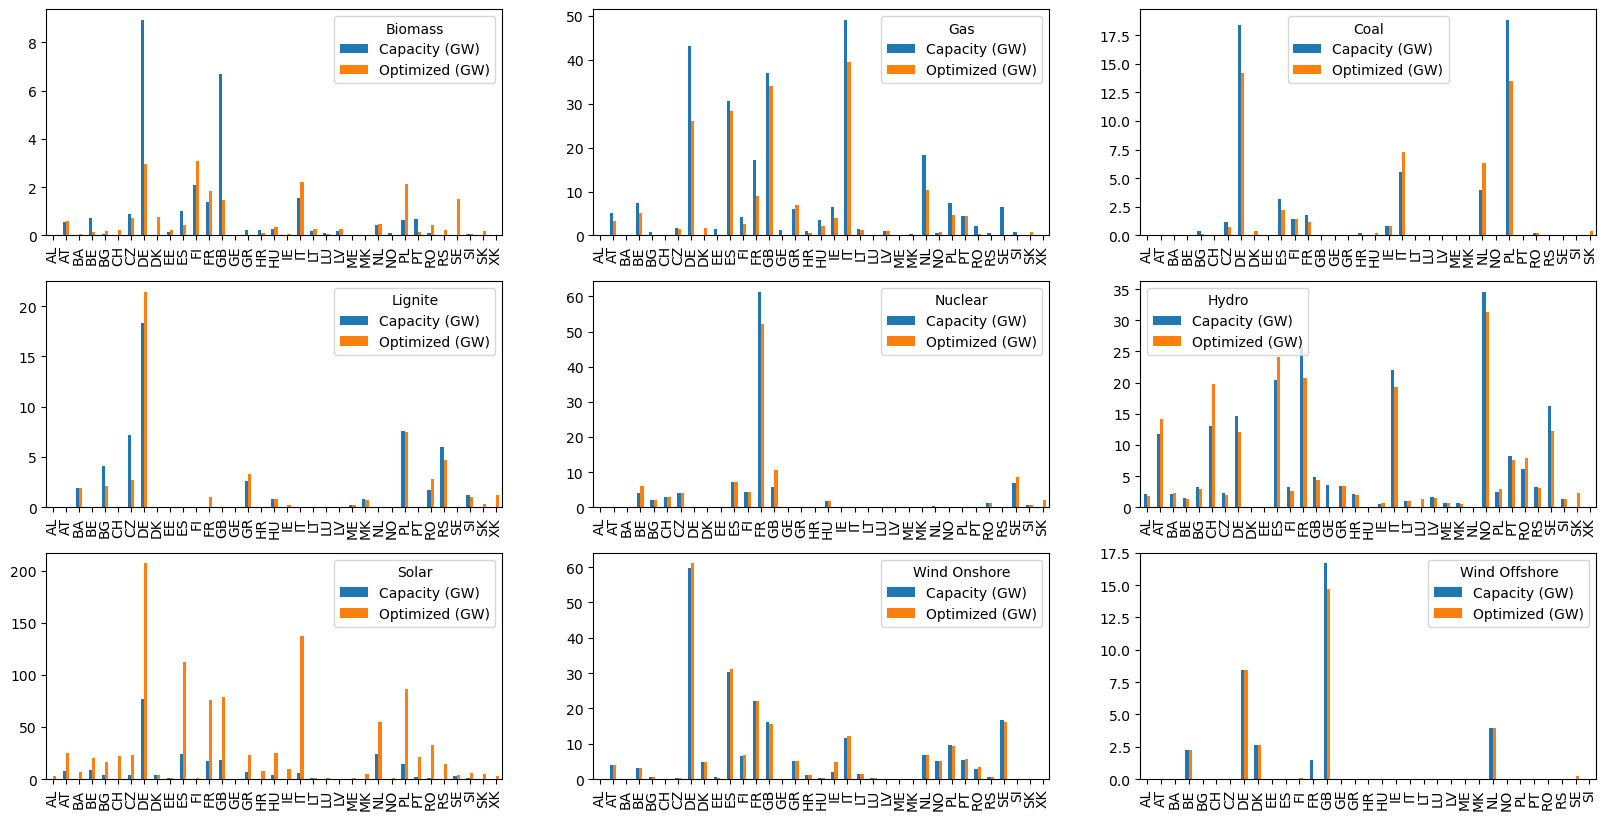

In [200]:
fig, axs = plt.subplots(3, 3, figsize=(20, 10))

for (nc, pypsa_carriers, comp), ax in zip(plot_carriers, axs.flatten()):

    if isinstance(comp, str):
        gen = getattr(n, comp).loc[getattr(n, comp).carrier.isin(pypsa_carriers), 'p_nom_opt']

        if comp == 'links':
            eta = n.links.loc[n.links.carrier.isin(pypsa_carriers), 'efficiency']
            gen = gen.mul(eta)
    else:
        gens = []
        for c, ps in zip(comp, pypsa_carriers):
            this_gen = getattr(n, c).loc[getattr(n, c).carrier == ps, 'p_nom_opt']
            gens.append(this_gen)
        gen = pd.concat(gens)

    gen = gen.groupby(gen.index.str[:2]).sum()

    df = pd.DataFrame({
        'Capacity (GW)': cap.loc[nc],
        'Optimized (GW)': gen
    }).fillna(0).mul(1e-3)

    df.plot.bar(ax=ax)
    ax.legend(title=nc)

plt.show()


In [201]:
n.generators.loc[n.generators.carrier == 'solar rooftop'].iloc[[0]].T

Generator,AL0 0 0 solar rooftop-2025
bus,AL0 0 low voltage
control,PQ
type,
p_nom,0.0
p_nom_mod,0.0
p_nom_extendable,True
p_nom_min,0.0
p_nom_max,5281.542575
p_min_pu,0.0
p_max_pu,1.0


In [176]:
wind = n.generators.loc[n.generators.carrier == 'solar', ['p_nom', 'p_nom_opt', 'p_nom_extendable']]
wind = wind.groupby(wind.index.str[:2]).agg(
    {'p_nom': 'sum', 'p_nom_opt': 'sum', 'p_nom_extendable': 'max'}
)
wind

,p_nom,p_nom_opt,p_nom_extendable
Generator,,,
AL,162.000000,162.000000,False
AT,6832.686000,6832.686000,False
BA,123.720000,123.720000,False
BE,8547.100000,8547.100000,False
BG,2948.184000,2948.184000,False
CH,5839.920000,5839.920000,False
CZ,2505.695000,2505.695000,False
DE,81737.000000,81737.000000,False
DK,3522.000000,3522.000000,False


In [ ]:
n.links.carrier